In [2]:
import copy
import json, pickle
import glob

import numpy as np
import pandas as pd

from qiskit import transpile
from qiskit.primitives import BackendEstimator
from qiskit_ibm_runtime import Estimator as RuntimeEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit import execute
from qiskit.providers.fake_provider import FakeLima, FakeSherbrooke, FakeLimaV2, FakeWashington
from qiskit import QuantumCircuit, IBMQ, QuantumRegister, ClassicalRegister
from qiskit.primitives import Estimator
from qiskit.circuit.random import random_circuit

import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.functional import dropout

from torch_geometric.nn import GCNConv, global_mean_pool, Linear, ChebConv, SAGEConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from tqdm.notebook import tqdm_notebook
import matplotlib.pyplot as plt
import seaborn as sns

from blackwater.data.loaders.exp_val import CircuitGraphExpValMitigationDataset
from blackwater.data.generators.exp_val import exp_value_generator
from blackwater.data.utils import generate_random_pauli_sum_op
from blackwater.library.ngem.estimator import ngem

from qiskit.quantum_info import random_clifford

import random
from qiskit.circuit.library import HGate, SdgGate
from qiskit.circuit import ClassicalRegister

from blackwater.data.utils import (
    generate_random_pauli_sum_op,
    create_estimator_meas_data,
    circuit_to_graph_data_json,
    get_backend_properties_v1,
    encode_pauli_sum_op,
    create_meas_data_from_estimators
)
from blackwater.data.generators.exp_val import ExpValueEntry
from blackwater.metrics.improvement_factor import improvement_factor, Trial, Problem

from qiskit_aer import AerSimulator, QasmSimulator
from qiskit.providers.fake_provider import FakeMontreal, FakeLima, FakeBelem

from torch_geometric.nn import (
    GCNConv,
    TransformerConv,
    GATv2Conv,
    global_mean_pool,
    Linear,
    ChebConv,
    SAGEConv,
    ASAPooling,
    dense_diff_pool,
    avg_pool_neighbor_x
)
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj, to_dense_batch

from qiskit import QuantumCircuit
from qiskit.circuit.library import U3Gate, CZGate, PhaseGate, CXGate
from mbd_utils import construct_random_clifford, cal_z_exp, calc_imbalance, cal_all_z_exp, construct_mbl_circuit, generate_disorder, random_clifford_circuit
from gnn import ExpValCircuitGraphModel
from qiskit.quantum_info import Clifford
from qiskit_aer.noise import depolarizing_error, coherent_unitary_error, NoiseModel
from noise_utils import AddNoise

from functools import partial

from zne import zne, ZNEStrategy
from zne.noise_amplification import *
from zne.extrapolation import *

D = {'output': 'mpl', 'fold': -1, 'idle_wires': False}

ImportError: cannot import name 'BackendEstimator' from 'qiskit.primitives' (/home/alitousi/miniconda3/envs/mlqem-3/lib/python3.13/site-packages/qiskit/primitives/__init__.py)

In [14]:
import copy
import glob
import json
import pickle
import random

import numpy as np
import pandas as pd
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.functional import dropout

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, TransformerConv, GATv2Conv, global_mean_pool,
    Linear, ChebConv, SAGEConv, ASAPooling,
    dense_diff_pool, avg_pool_neighbor_x
)
from torch_geometric.utils import to_dense_adj, to_dense_batch

from tqdm.notebook import tqdm_notebook
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────────────────────
# Qiskit / IBM Runtime
# ────────────────────────────────────────────────────────────────
from qiskit import (
    QuantumCircuit,
    transpile,
    # execute,
    # IBMQ
)
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Estimator as RuntimeEstimator,
    Session
)
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, coherent_unitary_error
from qiskit_aer.primitives import Estimator as AerEstimator

from qiskit.quantum_info import (
    SparsePauliOp,
    random_clifford,
    Clifford
)
from qiskit_ibm_runtime.fake_provider import (
    FakeSherbrooke, FakeLimaV2,
    FakeFez
)
from qiskit.circuit.library import (
    HGate, SdgGate,
    U3Gate, CZGate, PhaseGate, CXGate
)
from qiskit.circuit.random import random_circuit

# ────────────────────────────────────────────────────────────────
# Blackwater / ZNE / MBD / GNN utilities
# ────────────────────────────────────────────────────────────────
from blackwater.data.loaders.exp_val import CircuitGraphExpValMitigationDataset
from blackwater.data.generators.exp_val import exp_value_generator, ExpValueEntry
from blackwater.data.utils import (
    generate_random_pauli_sum_op,
    create_estimator_meas_data,
    circuit_to_graph_data_json,
    get_backend_properties_v1,
    encode_pauli_sum_op,
    create_meas_data_from_estimators
)
from blackwater.library.ngem.estimator import ngem

from mbd_utils import (
    construct_random_clifford,
    cal_z_exp, cal_all_z_exp, calc_imbalance,
    construct_mbl_circuit,
    generate_disorder, random_clifford_circuit
)
from gnn import ExpValCircuitGraphModel
from noise_utils import AddNoise

from zne import zne, ZNEStrategy
from zne.noise_amplification import *
from zne.extrapolation import *

# ────────────────────────────────────────────────────────────────
# Misc
# ────────────────────────────────────────────────────────────────
D = {'output': 'mpl', 'fold': -1, 'idle_wires': False}


ModuleNotFoundError: No module named 'blackwater'

In [9]:
from qiskit_ibm_provider import IBMProvider
provider = IBMProvider()

In [10]:
# real_backend = provider.get_backend('ibm_sherbrooke')
real_backend = provider.get_backend('ibm_brisbane')

In [11]:
fake_backend = FakeSherbrooke()

## Local
fake_backend_ideal = QasmSimulator() # Noiseless
fake_backend_noisy = AerSimulator.from_backend(fake_backend) # Noisy
stabilizer_simulator = AerSimulator(method='extended_stabilizer')

fake_run_config_ideal = {'shots': 10000, 'backend': fake_backend_ideal, 'name': 'fake_ideal'}
fake_run_config_noisy = {'shots': 10000, 'backend': fake_backend_noisy, 'name': 'fake_noisy'}

In [12]:
from qiskit.circuit import Parameter

class IsingModel:

    class Options(dict):
        def __init__(self, *args, **kwargs):
            super().__init__()
            self['nq'] = 4
            self['h'] = 1
            self['J'] = 0.15
            self['dt'] = 1/4
            self['depth'] = 15
            self.update(*args, **kwargs)

        def config_4q_paper(self):
            self['h'] = 1
            self['J'] = 0.15
            self['dt'] = 1/4*2

        def config_100q_paper_Clifford(self):
            self['nq'] = 100
            self['h'] = 0.5*np.pi
            self['J'] = 0.15
            self['dt'] = 1/4*2

        def config_100q_paper_nonClifford(self):
            self['nq'] = 100
            self['h'] = 0.66*np.pi
            self['J'] = 0.15
            self['dt'] = 1/4*2

        def config_6q_paper(self):
            self['nq'] = 6
            self['h'] = np.pi
            self['J'] = 0.15
            self['dt'] = 1/4*2

    @classmethod
    def apply_quantum_circuit_layer(cls, qc: QuantumCircuit, ops: 'IsingModel.Options'):
        allq = list(range(ops['nq']))

        qc.rx(2*ops['h']*ops['dt'], allq)

        qc.barrier()
        for q0 in allq[0::2]:
            q1 = q0+1
            qc.cx(q0,q1)
        qc.rz(-2*ops['J']*ops['dt'], allq[1::2])
        for q0 in allq[0::2]:
            q1 = q0+1
            qc.cx(q0,q1)

        qc.barrier()
        for q0 in allq[1:-2:2]:
            q1 = q0+1
            qc.cx(q0,q1)
        qc.rz(-2*ops['J']*ops['dt'], allq[2:-1:2])
        for q0 in allq[1:-2:2]:
            q1 = q0+1
            qc.cx(q0,q1)
        qc.barrier()

    @classmethod
    def make_quantum_circuit(cls, ops: 'IsingModel.Options'):
        qc = QuantumCircuit(ops['nq'])
        allq = list(range(ops['nq']))

        for step in range(ops['depth']):
            cls.apply_quantum_circuit_layer(qc, ops)

        if ops['measure_basis'] == 'Z':
            pass
        elif  ops['measure_basis'] == 'X':
            qc.h(allq)
        elif  ops['measure_basis'] == 'Y':
            qc.sdg(allq)
            qc.h(allq)
        else:
            raise Exception("Must be X Y or Z")
        qc.measure_all()

        return qc

    @classmethod
    def make_circs_sweep(cls, ops, num_steps, measure_basis):
        ops['measure_basis'] = measure_basis
        ops['depth'] = num_steps
        qc = cls.make_quantum_circuit(ops)
        qc.metadata = {}
        qc.metadata['measure_basis'] = measure_basis
        qc.metadata['depth'] = num_steps
        return qc

In [13]:
brisbane_layout = list(range(113, 127)) + [112] + list(range(108, 93, -1)) + [90] + list(range(75, 90)) + [74] + list(range(70, 55, -1)) + [52] + list(range(37, 44)) + [34] + list(range(24, 17, -1)) + [14] + list(range(0, 13)) + [17, 30, 31, 32, 36, 51, 50, 49]

print(len(brisbane_layout))

100


In [14]:
from qiskit.transpiler.passes import RemoveBarriers
def construct_ising_circuit_100q_Clifford(J, basis, num_steps):
    cls = IsingModel
    ops = cls.Options()
    ops.config_100q_paper_Clifford()
    ops.update({'J': J})
    qc = cls.make_circs_sweep(ops, num_steps, basis)
    return qc

def construct_ising_circuit_100q_nonClifford(J, basis, num_steps):
    cls = IsingModel
    ops = cls.Options()
    ops.config_100q_paper_nonClifford()
    ops.update({'J': J})
    qc = cls.make_circs_sweep(ops, num_steps, basis)
    return qc

def construct_ising_circuit_4q_nonClifford(J, basis, num_steps):
    cls = IsingModel
    ops = cls.Options()
    ops.config_4q_paper()
    ops.update({'J': J})
    qc = cls.make_circs_sweep(ops, num_steps, basis)
    return qc

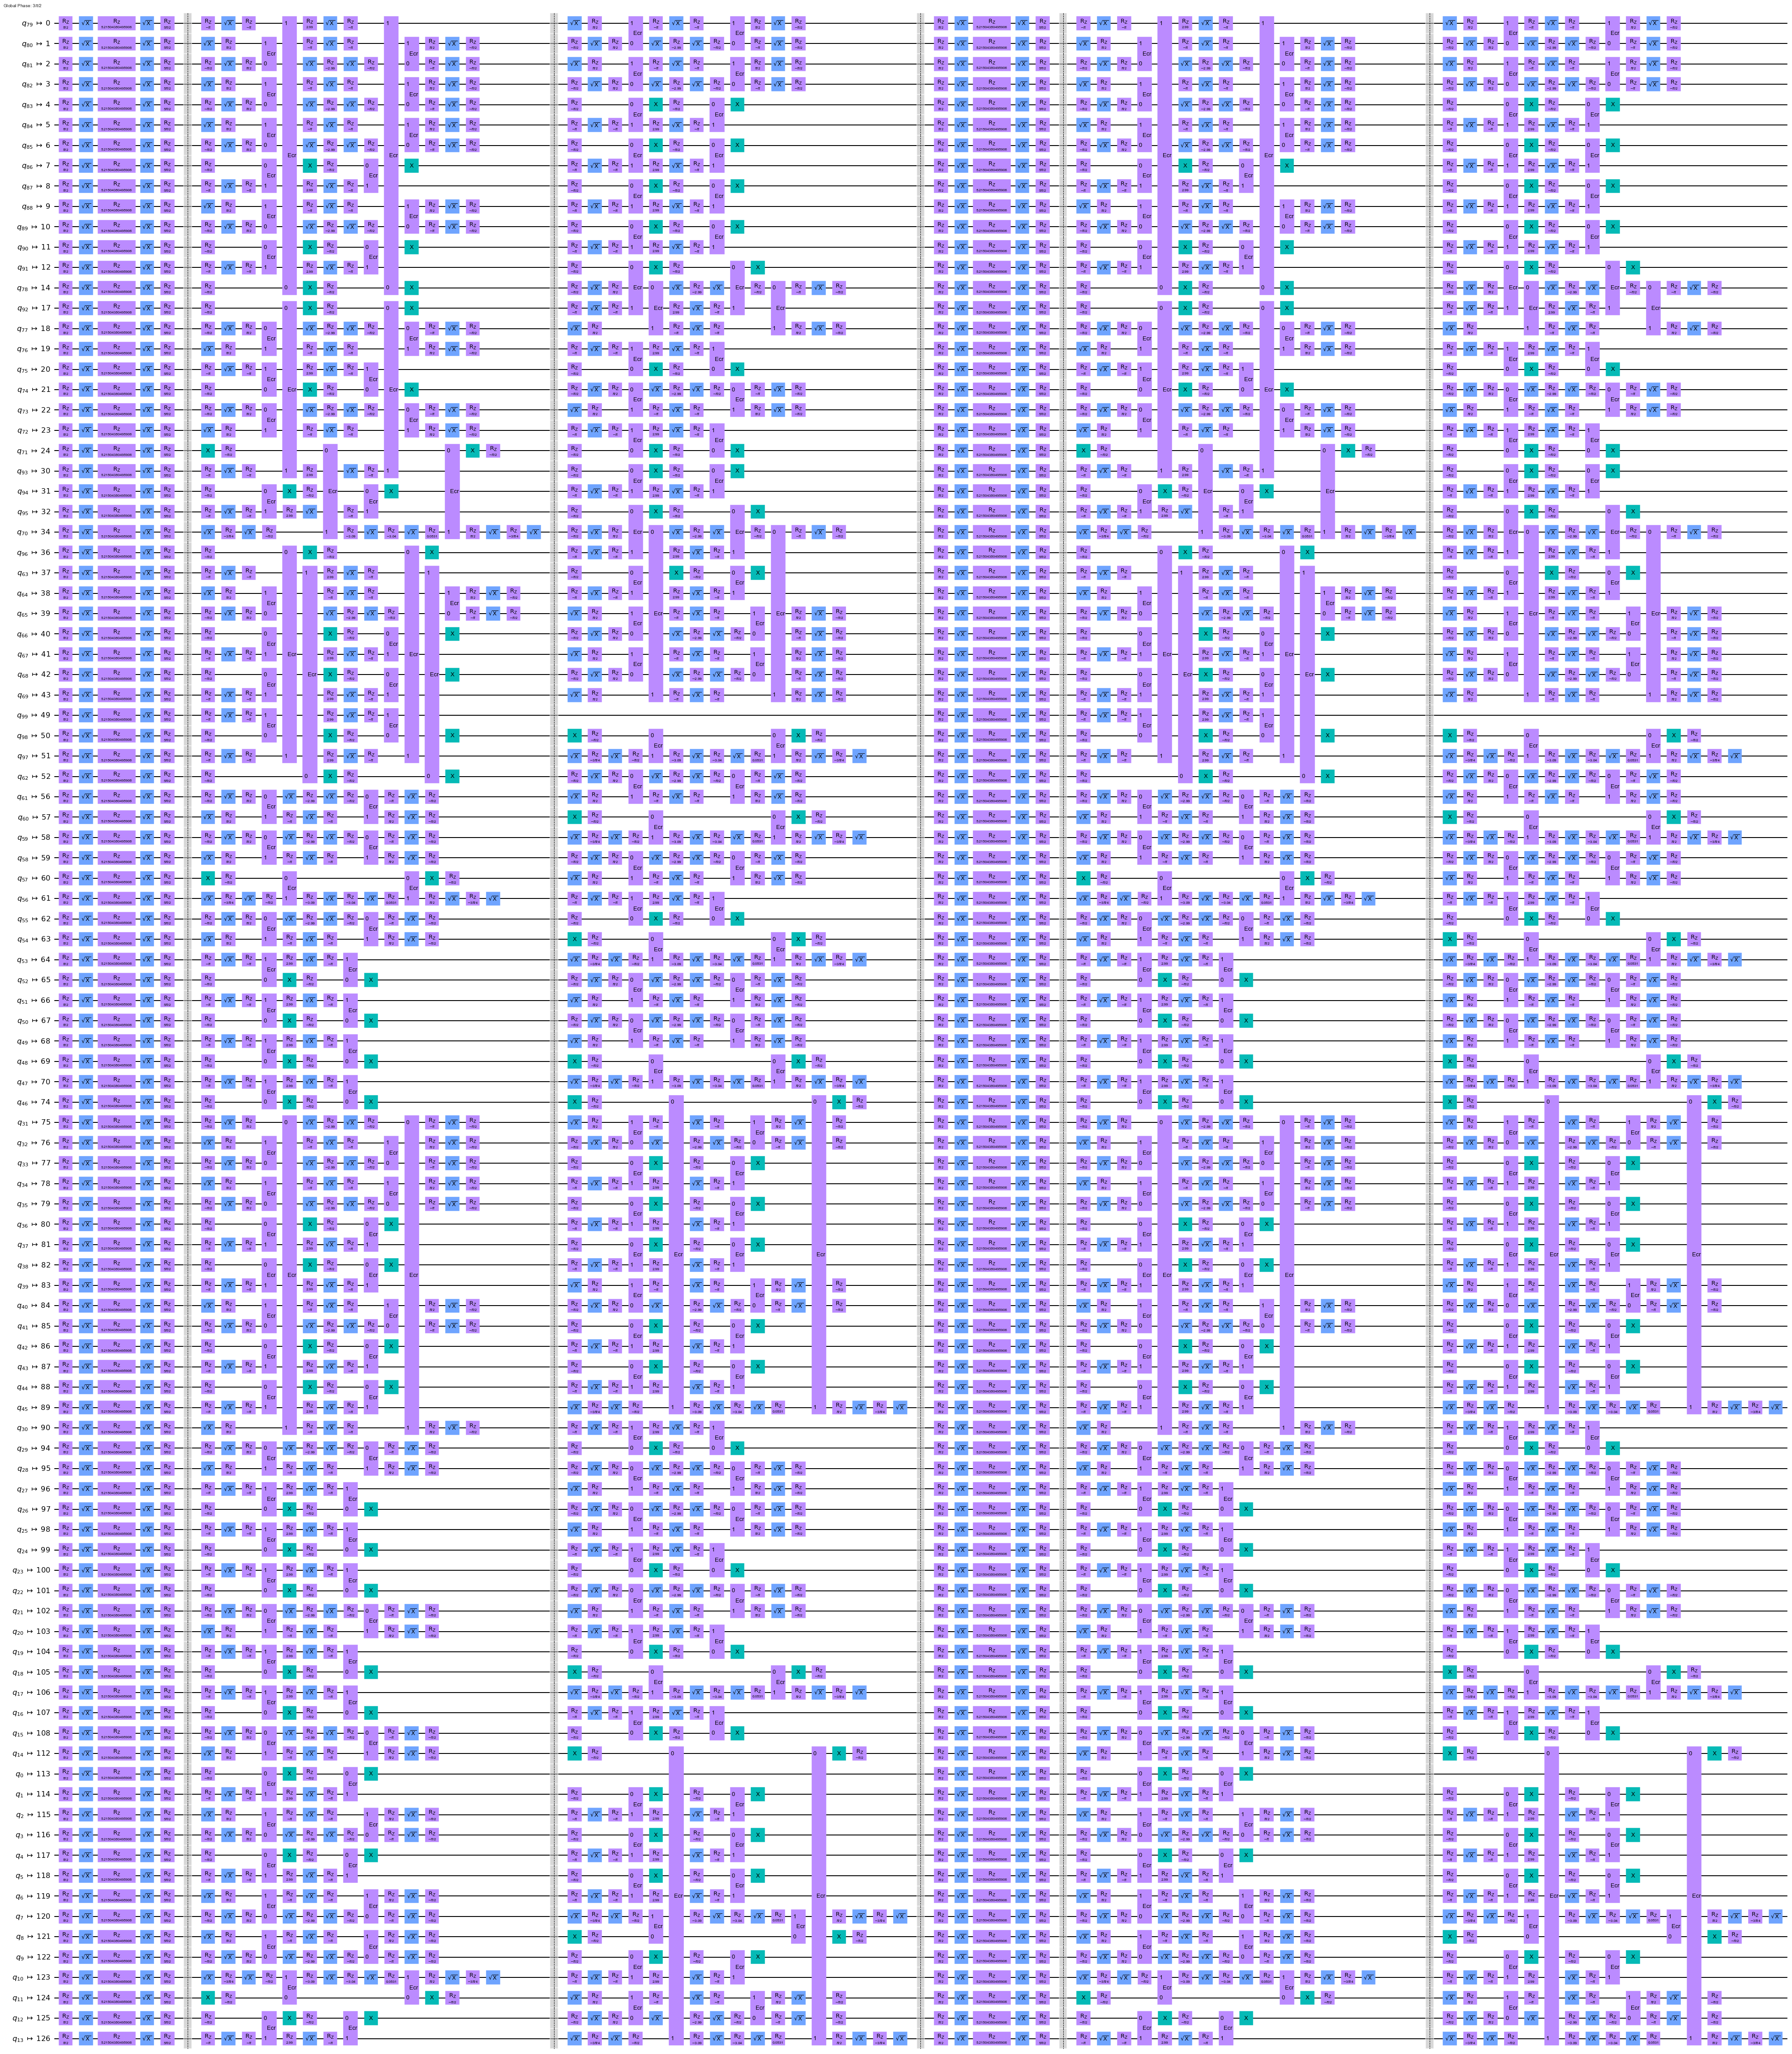

In [43]:
J = 0.15
basis = 'Z'
random_ising = construct_ising_circuit_100q_nonClifford(J, basis, 2)
# random_ising = RemoveBarriers()(random_ising)
trans_circuit = transpile(
    random_ising,
    backend=real_backend,
    optimization_level=3,
    initial_layout=brisbane_layout,
)
trans_circuit.remove_final_measurements()
trans_circuit.draw(**D)

In [15]:
def form_all_qubit_observable(observable, measurement_qubits, total_num_qubits):
    """Input observable in non-endian, output observable in endian"""
    assert len(observable) == len(measurement_qubits)
    converted_obs = list('I' * total_num_qubits)
    for qubit, basis in zip(measurement_qubits, list(observable)):
        converted_obs[qubit] = basis
    return ''.join(converted_obs)[::-1]

def get_measurement_qubits(qc, num_measured_qubit):
    measurement_qubits = []
    for measurement in range(num_measured_qubit - 1, -1, -1):
        measurement_qubits.append(qc.data[-1 - measurement][1][0].index)
    return measurement_qubits

def get_Js(num_Js, num_q):
    np.random.seed(42)
    if num_q == 100:
        h = np.pi * 0.66
    else:
        raise NotImplementedError
    return np.random.uniform(0, h, size=num_Js)

from pec_runtime.utils.stratify import stratify_circuit_into_layers
from pec_runtime.circuit import TwirledCircuit

def construct_random_ising_sameJ_twirled_nonCliff_func(J, be, num_q, num_steps, num_twirl=2):
    basis = 'Z'
    if num_q == 100:
        random_ising = construct_ising_circuit_100q_nonClifford(J, basis, num_steps)
    else:
        raise NotImplementedError

    random_ising.remove_final_measurements()
    layers = stratify_circuit_into_layers(random_ising, twirled_qubits=list(range(num_q)))
    twirled_body = TwirledCircuit(layers, barriers=True)
    random_ising_list = twirled_body.sample_circuits(num_samples=num_twirl)

    ranges_to_remove = [(i, i+6) for i in range(1, 100, 8)]
    random_ising_list_opt = []
    for circuit in random_ising_list:
        new_circuit = QuantumCircuit(*circuit.qregs)
        barrier_count = 0
        for op, qubits, _ in circuit.data:
            if op.name == 'barrier':
                barrier_count += 1
                if any(start <= barrier_count <= end for start, end in ranges_to_remove):
                    continue
            new_circuit.append(op, qubits)
        random_ising_list_opt.append(new_circuit)

    for i in range(len(random_ising_list_opt)):
        random_ising_list_opt[i].measure_all()

    trans_circuits = transpile(
        random_ising_list_opt,
        backend=be,
        optimization_level=3,
        initial_layout=brisbane_layout,
    )
    return trans_circuits, J

def construct_random_ising_sameJ_twirled_Cliff_func(be, num_q, num_steps, num_twirl=2):
    basis = 'Z'
    if num_q == 100:
        random_ising = construct_ising_circuit_100q_Clifford(0, basis, num_steps)
    else:
        raise NotImplementedError

    random_ising.remove_final_measurements()
    layers = stratify_circuit_into_layers(random_ising, twirled_qubits=list(range(num_q)))
    twirled_body = TwirledCircuit(layers, barriers=True)
    random_ising_list = twirled_body.sample_circuits(num_samples=num_twirl)

    ranges_to_remove = [(i, i+6) for i in range(1, 100, 8)]
    random_ising_list_opt = []
    for circuit in random_ising_list:
        new_circuit = QuantumCircuit(*circuit.qregs)
        barrier_count = 0
        for op, qubits, _ in circuit.data:
            if op.name == 'barrier':
                barrier_count += 1
                if any(start <= barrier_count <= end for start, end in ranges_to_remove):
                    continue
            new_circuit.append(op, qubits)
        random_ising_list_opt.append(new_circuit)

    for i in range(len(random_ising_list_opt)):
        random_ising_list_opt[i].measure_all()

    trans_circuits = transpile(
        random_ising_list_opt,
        backend=be,
        optimization_level=2,
        initial_layout=brisbane_layout,
    )
    return trans_circuits, 0

In [45]:
trans_circuits, J = construct_random_ising_sameJ_twirled_nonCliff_func(0.1, real_backend, 100, 4)

In [46]:
trans_circuits[0].draw(**D)

In [47]:
trans_circuits, J = construct_random_ising_sameJ_twirled_Cliff_func(real_backend, 100, 2)

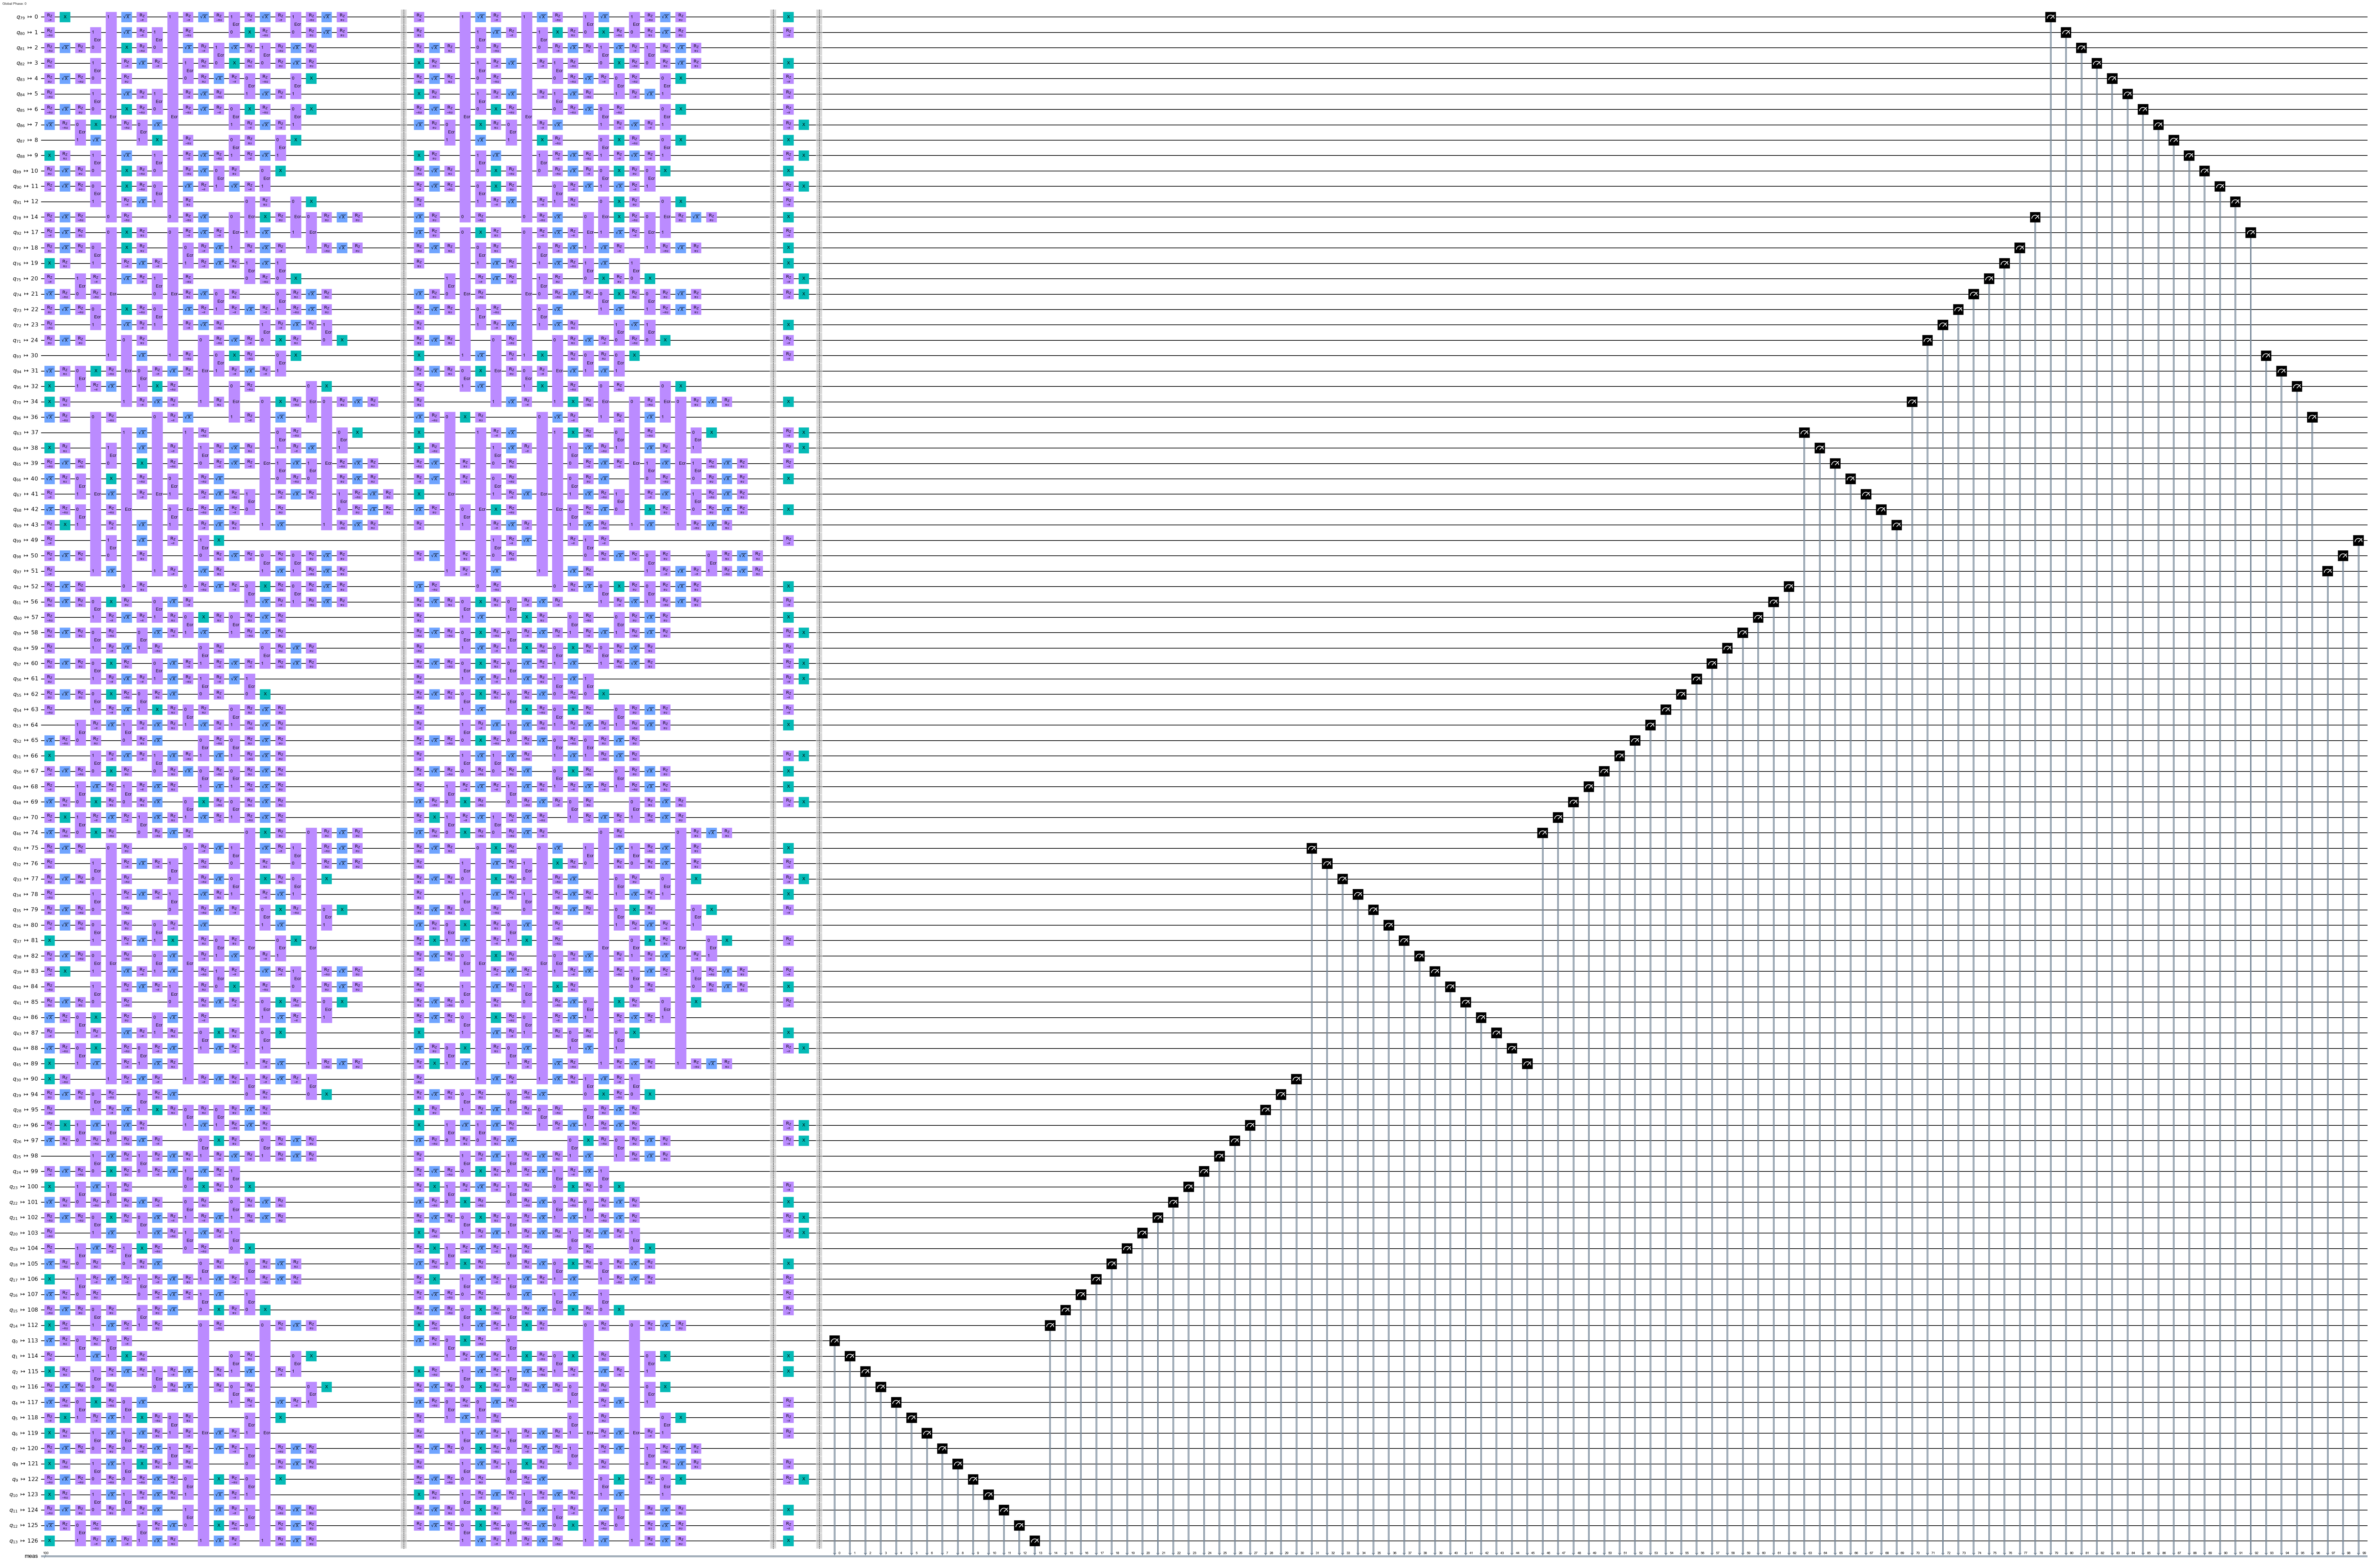

In [48]:
trans_circuits[0].draw(**D)

In [49]:
from qiskit.transpiler.exceptions import TranspilerError
import scipy

def generate_data(two_q_gate_depths, save_path: str, n_Js: int, be, num_q):
    Js = get_Js(n_Js, num_q)
    for depth in two_q_gate_depths:

        trans_circuits_twirled, J = construct_random_ising_sameJ_twirled_Cliff_func(be, num_q, depth, num_twirl=5)

        entries = []
        for circuit_twirled in trans_circuits_twirled:
            to_append = dict()
            to_append['circuit_twirled'] = circuit_twirled
            to_append['steps'] = depth
            to_append['J'] = 0
            entries.append(to_append)

        path = "%s/step_%02d_J%02d.pk"%(save_path, depth, 0)
        with open(path, "wb") as f:
            pickle.dump(entries, f)

        for i in tqdm_notebook(range(1, n_Js)):

            trans_circuits_twirled, J = construct_random_ising_sameJ_twirled_nonCliff_func(J=Js[i], be=be, num_q=num_q, num_steps=depth, num_twirl=5)

            entries = []
            for circuits_twirled in trans_circuits_twirled:
                to_append = dict()
                to_append['circuit_twirled'] = circuits_twirled
                to_append['steps'] = depth
                to_append['J'] = J
                entries.append(to_append)

            path = "%s/step_%02d_J%02d.pk"%(save_path, depth, i)
            with open(path, "wb") as f:
                pickle.dump(entries, f)

random.seed(42)
np.random.seed(42)
steps = list(range(8, 11))
generate_data(steps,
              './data/ising_zne_hardware_twirled/100q_brisbane',
              50,
              real_backend,
              num_q=100)

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

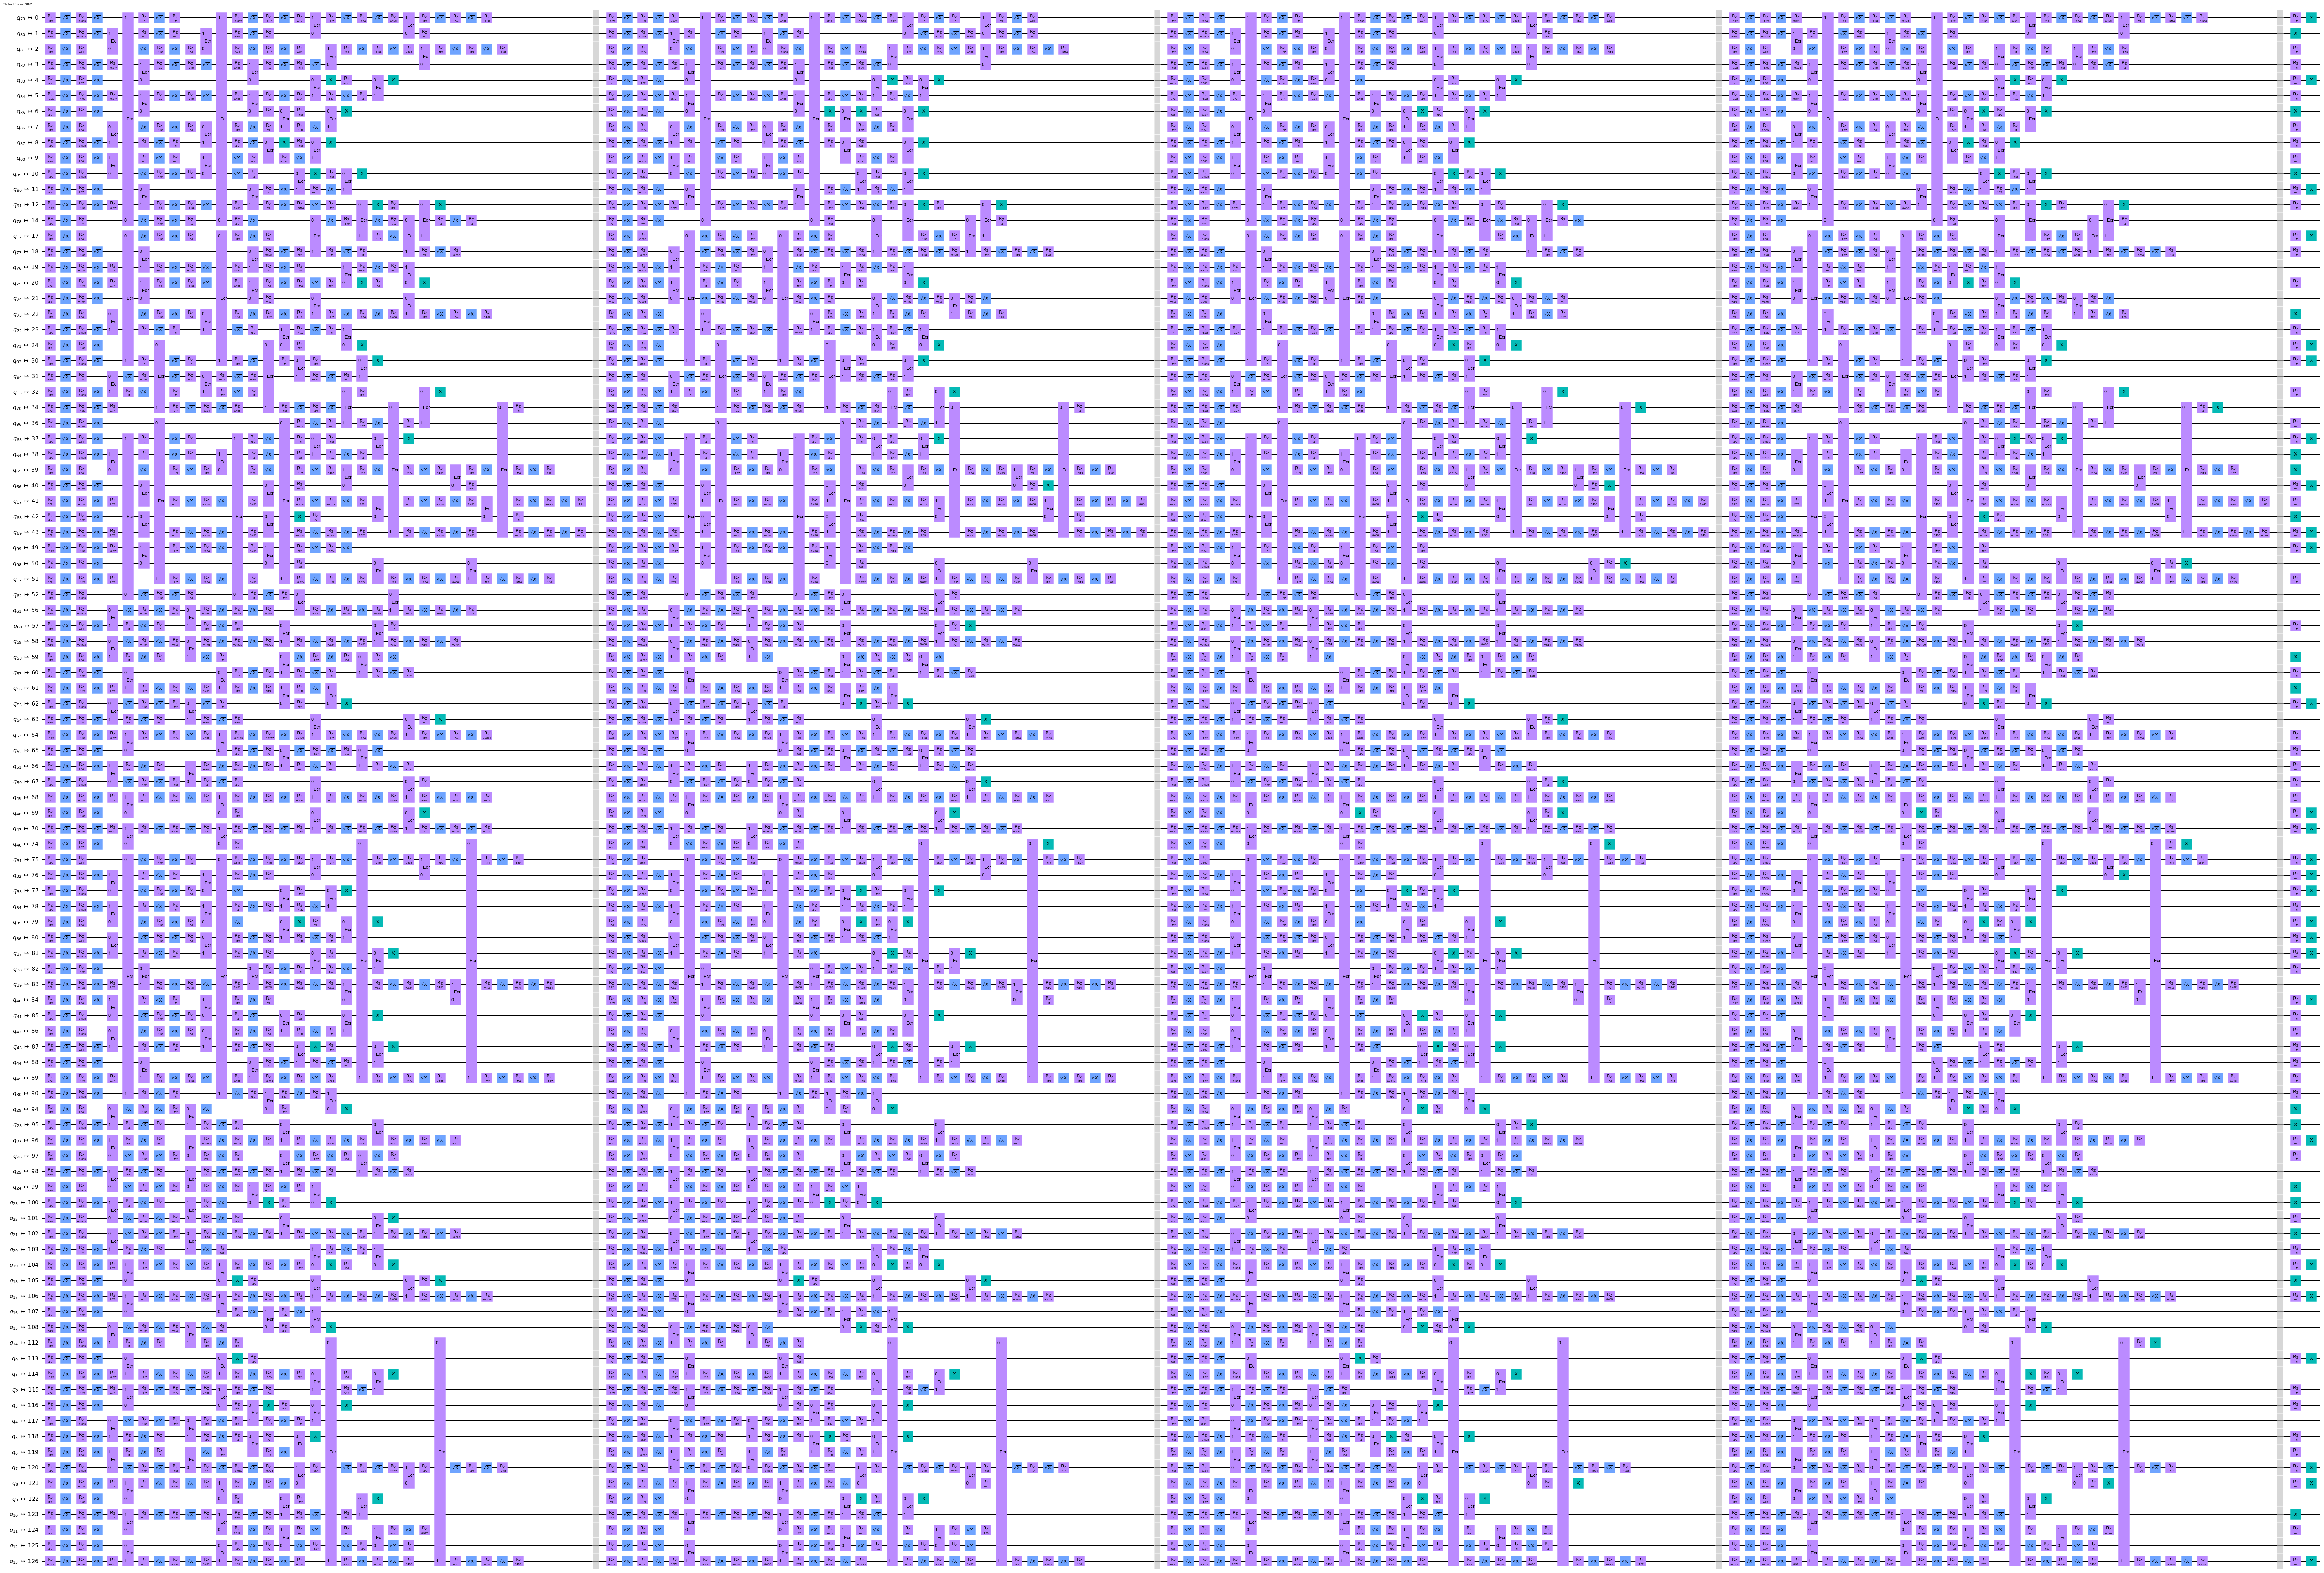

In [52]:
with open('./data/ising_zne_hardware_twirled/100q_brisbane/circuits/step_04_J01.pk', 'rb') as file:
    loaded = pickle.load(file)

circ = loaded[1]['circuit_twirled']
circ.remove_final_measurements()
circ.draw(**D)

# Generate non-twirled circuit

In [19]:
def construct_random_ising_sameJ_nonCliff_func(J, be, num_q, num_steps):
    basis = 'Z'
    if num_q == 100:
        random_ising = construct_ising_circuit_100q_nonClifford(J, basis, num_steps)
    else:
        raise NotImplementedError

    trans_circuit = transpile(
        random_ising,
        backend=be,
        optimization_level=3,
        initial_layout=brisbane_layout,
    )
    return trans_circuit, J


def construct_random_ising_sameJ_Cliff_func(be, num_q, num_steps):
    basis = 'Z'
    if num_q == 100:
        random_ising = construct_ising_circuit_100q_Clifford(0, basis, num_steps)
    else:
        raise NotImplementedError

    trans_circuit = transpile(
        random_ising,
        backend=be,
        optimization_level=2,
        initial_layout=brisbane_layout,
    )
    return trans_circuit, 0

def generate_data(two_q_gate_depths, save_path: str, n_Js: int, be, num_q):
    Js = get_Js(n_Js, num_q)
    for depth in two_q_gate_depths:

        trans_circuit, J = construct_random_ising_sameJ_Cliff_func(be, num_q, depth)

        entries = []
        for circuit_twirled in [trans_circuit]:
            to_append = dict()
            to_append['circuit'] = circuit_twirled
            to_append['steps'] = depth
            to_append['J'] = 0
            entries.append(to_append)

        path = "%s/step_%02d_J%02d.pk" % (save_path, depth, 0)
        with open(path, "wb") as f:
            pickle.dump(entries, f)

        for i in tqdm_notebook(range(1, n_Js)):

            trans_circuit, J = construct_random_ising_sameJ_nonCliff_func(J=Js[i], be=be, num_q=num_q, num_steps=depth)

            entries = []
            for circuits_twirled in [trans_circuit]:
                to_append = dict()
                to_append['circuit'] = circuits_twirled
                to_append['steps'] = depth
                to_append['J'] = J
                entries.append(to_append)

            path = "%s/step_%02d_J%02d.pk" % (save_path, depth, i)
            with open(path, "wb") as f:
                pickle.dump(entries, f)


random.seed(42)
np.random.seed(42)
steps = list(range(1, 11))
generate_data(steps,
              './data/ising_zne_hardware/100q_brisbane',
              50,
              real_backend,
              num_q=100)

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]